# EDA: Brazilian E-Commerce Public Dataset by Olist

Este análisis mantiene la granularidad original de cada CSV para preparar un modelo estrella de ventas y logística. Los merges se hacen únicamente cuando la granularidad es compatible y se cuantifica el riesgo de multiplicación de filas.

In [13]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", palette="Set2")

DATA_DIR = Path("../data")
FILE_MAP = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}


def load_datasets(data_dir=DATA_DIR):
    """Carga cada CSV por separado y devuelve un diccionario de DataFrames."""
    datasets = {}
    for table_name, file_name in FILE_MAP.items():
        path = Path(data_dir) / file_name
        datasets[table_name] = pd.read_csv(path)
        print(f"{table_name:22s} {datasets[table_name].shape} <- {path}")
    return datasets


def profile_table(df, table_name):
    """Resume tamaño, tipos, nulos, cardinalidad y memoria por columna."""
    profile = pd.DataFrame({
        "table": table_name,
        "dtype": df.dtypes.astype(str),
        "rows": len(df),
        "null_count": df.isna().sum(),
        "null_pct": df.isna().mean().mul(100),
        "unique_count": df.nunique(dropna=False),
        "memory_bytes": df.memory_usage(deep=True, index=False),
    })
    return profile.reset_index(names="column")


def key_check(df, table_name, key_columns):
    """Comprueba nulos y unicidad de la llave declarada."""
    duplicate_rows = int(df.duplicated(subset=key_columns).sum())
    null_rows = int(df[list(key_columns)].isna().any(axis=1).sum())
    return {
        "table": table_name,
        "key": ", ".join(key_columns),
        "is_unique": duplicate_rows == 0 and null_rows == 0,
        "duplicate_key_rows": duplicate_rows,
        "null_key_rows": null_rows,
    }


def relationship_cardinality(left, right, key, left_name, right_name):
    """Clasifica la relación observada usando repeticiones de la llave en ambos lados."""
    left_counts = left[key].value_counts(dropna=False)
    right_counts = right[key].value_counts(dropna=False)
    shared = left_counts.index.intersection(right_counts.index)
    left_many = bool((left_counts.loc[shared] > 1).any()) if len(shared) else False
    right_many = bool((right_counts.loc[shared] > 1).any()) if len(shared) else False
    if left_many and right_many:
        cardinality = "N:M"
    elif left_many:
        cardinality = "N:1"
    elif right_many:
        cardinality = "1:N"
    else:
        cardinality = "1:1"
    return {
        "left": left_name,
        "right": right_name,
        "key": key,
        "shared_keys": len(shared),
        "cardinality": cardinality,
        "left_keys_with_duplicates": int((left_counts.loc[shared] > 1).sum()) if len(shared) else 0,
        "right_keys_with_duplicates": int((right_counts.loc[shared] > 1).sum()) if len(shared) else 0,
    }


def add_datetime_columns(df, columns):
    """Convierte columnas de fecha a datetime sin detener el análisis por valores inválidos."""
    result = df.copy()
    for column in columns:
        if column in result:
            result[column] = pd.to_datetime(result[column], errors="coerce")
    return result


def iqr_outlier_summary(df, column):
    """Calcula límites IQR y cuenta valores extremos de una columna numérica."""
    values = df[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((values < lower) | (values > upper)).sum())
    return {"column": column, "q1": q1, "q3": q3, "lower": lower, "upper": upper, "outlier_count": count, "outlier_pct": count / len(values) * 100}


def null_decision(column, null_pct):
    """Propone una acción de calidad según el rol habitual de la columna."""
    key_words = ("id", "timestamp", "date")
    if null_pct == 0:
        return "Conservar; no presenta nulos"
    if any(word in column.lower() for word in key_words):
        return "Investigar; excluir de joins si la llave es nula"
    return "Imputar, conservar como 'desconocido' o excluir solo según el KPI"


datasets = load_datasets()


orders                 (99441, 8) <- ..\data\olist_orders_dataset.csv
order_items            (112650, 7) <- ..\data\olist_order_items_dataset.csv
order_payments         (103886, 5) <- ..\data\olist_order_payments_dataset.csv
order_reviews          (99224, 7) <- ..\data\olist_order_reviews_dataset.csv
products               (32951, 9) <- ..\data\olist_products_dataset.csv
customers              (99441, 5) <- ..\data\olist_customers_dataset.csv
sellers                (3095, 4) <- ..\data\olist_sellers_dataset.csv
geolocation            (1000163, 5) <- ..\data\olist_geolocation_dataset.csv
category_translation   (71, 2) <- ..\data\product_category_name_translation.csv


## 1. Carga, perfilado y llaves

Cada tabla se inspecciona en su granularidad original. Las llaves se declaran explícitamente porque una clave técnica repetida puede ser correcta en una tabla de hechos.

In [14]:
profiles = pd.concat(
    [profile_table(df, name) for name, df in datasets.items()],
    ignore_index=True,
)
print("Perfil completo por columna:")
display(profiles.sort_values(["table", "column"]))
print(f"Memoria total: {profiles['memory_bytes'].sum() / 1024**2:,.2f} MiB")

primary_keys = {
    "orders": ["order_id"],
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["review_id"],
    "products": ["product_id"],
    "customers": ["customer_id"],
    "sellers": ["seller_id"],
    "geolocation": ["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"],
    "category_translation": ["product_category_name"],
}
key_results = pd.DataFrame([
    key_check(datasets[name], name, key)
    for name, key in primary_keys.items()
])
print("Llaves declaradas y validación de unicidad:")
display(key_results)
print("Nota: order_id es único en orders, pero se repite en order_items porque esa tabla está a nivel de línea.")

Perfil completo por columna:


,column,table,dtype,rows,null_count,null_pct,unique_count,memory_bytes
50,product_category_name,category_translation,str,71,0,0.00,71,4684
51,product_category_name_english,category_translation,str,71,0,0.00,71,4620
39,customer_city,customers,str,99441,0,0.00,4119,5901273
36,customer_id,customers,str,99441,0,0.00,99441,8054721
40,customer_state,customers,str,99441,0,0.00,27,5071491
37,customer_unique_id,customers,str,99441,0,0.00,96096,8054721
38,customer_zip_code_prefix,customers,int64,99441,0,0.00,14994,795528
48,geolocation_city,geolocation,str,1000163,0,0.00,8011,61580270
46,geolocation_lat,geolocation,float64,1000163,0,0.00,717360,8001304
47,geolocation_lng,geolocation,float64,1000163,0,0.00,717613,8001304


Memoria total: 308.02 MiB
Llaves declaradas y validación de unicidad:


,table,key,is_unique,duplicate_key_rows,null_key_rows
0,orders,order_id,True,0,0
1,order_items,"order_id, order_item_id",True,0,0
2,order_payments,"order_id, payment_sequential",True,0,0
3,order_reviews,review_id,False,814,0
4,products,product_id,True,0,0
5,customers,customer_id,True,0,0
6,sellers,seller_id,True,0,0
7,geolocation,"geolocation_zip_code_prefix, geolocation_lat, ...",False,280009,0
8,category_translation,product_category_name,True,0,0


Nota: order_id es único en orders, pero se repite en order_items porque esa tabla está a nivel de línea.


## 2. Relaciones antes de hacer merge

La cardinalidad se calcula sobre las llaves observadas y solo para claves compartidas. Esto evita asumir que cada relación es 1:N.

In [15]:
relationship_specs = [
    ("orders", "order_items", "order_id"),
    ("orders", "order_payments", "order_id"),
    ("orders", "order_reviews", "order_id"),
    ("orders", "customers", "customer_id"),
    ("order_items", "products", "product_id"),
    ("order_items", "sellers", "seller_id"),
    ("products", "category_translation", "product_category_name"),
]
relationship_results = pd.DataFrame([
    relationship_cardinality(datasets[left], datasets[right], key, left, right)
    for left, right, key in relationship_specs
])
print("Cardinalidades observadas antes de mergear:")
display(relationship_results)

items_per_order = datasets["order_items"].groupby("order_id").size().rename("item_rows")
payments_per_order = datasets["order_payments"].groupby("order_id").size().rename("payment_rows")
order_multiplicity = pd.concat([items_per_order, payments_per_order], axis=1).fillna(0)
order_multiplicity["cartesian_rows"] = order_multiplicity["item_rows"] * order_multiplicity["payment_rows"]
order_multiplicity["duplication_introduced"] = np.maximum(order_multiplicity["cartesian_rows"] - order_multiplicity["item_rows"], 0)
orders_with_both_many = order_multiplicity.query("item_rows > 1 and payment_rows > 1")
print("Riesgo order_items x order_payments por order_id:")
print(f"Pedidos con múltiples líneas y múltiples pagos: {len(orders_with_both_many):,}")
print(f"Filas de líneas afectadas por el producto cartesiano: {orders_with_both_many['cartesian_rows'].sum() - orders_with_both_many['item_rows'].sum():,.0f}")
print(f"Filas resultantes para esos pedidos: {orders_with_both_many['cartesian_rows'].sum():,.0f}")
print("Advertencia: un merge directo por order_id duplica parcialmente la facturación; agregar pagos por pedido o mantener facts separadas.")

Cardinalidades observadas antes de mergear:


,left,right,key,shared_keys,cardinality,left_keys_with_duplicates,right_keys_with_duplicates
0,orders,order_items,order_id,98666,1:N,0,9803
1,orders,order_payments,order_id,99440,1:N,0,2961
2,orders,order_reviews,order_id,98673,1:N,0,547
3,orders,customers,customer_id,99441,1:1,0,0
4,order_items,products,product_id,32951,N:1,14834,0
5,order_items,sellers,seller_id,3095,N:1,2586,0
6,products,category_translation,product_category_name,71,N:1,70,0


Riesgo order_items x order_payments por order_id:
Pedidos con múltiples líneas y múltiples pagos: 275
Filas de líneas afectadas por el producto cartesiano: 999
Filas resultantes para esos pedidos: 1,622
Advertencia: un merge directo por order_id duplica parcialmente la facturación; agregar pagos por pedido o mantener facts separadas.


## 3. Calidad de datos y variables derivadas

Se distinguen nulos informativos de nulos que impedirían una relación. Las fechas se comparan solo cuando ambas existen, y los outliers se detectan con IQR.

In [16]:
null_report = profiles.loc[profiles["null_count"] > 0, ["table", "column", "null_count", "null_pct"]].copy()
null_report["suggested_decision"] = [null_decision(column, pct) for column, pct in zip(null_report["column"], null_report["null_pct"])]
print("Nulos y decisión sugerida:")
display(null_report.sort_values(["table", "null_pct"], ascending=[True, False]))

exact_duplicates = pd.DataFrame([
    {"table": name, "exact_duplicate_rows": int(df.duplicated().sum()), "exact_duplicate_pct": df.duplicated().mean() * 100}
    for name, df in datasets.items()
])
print("Duplicados exactos por tabla:")
display(exact_duplicates)

orders_dates = add_datetime_columns(
    datasets["orders"],
    ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"],
)
checks = {
    "purchase_after_approved": (orders_dates["order_purchase_timestamp"] > orders_dates["order_approved_at"]),
    "carrier_after_customer": (orders_dates["order_delivered_carrier_date"] > orders_dates["order_delivered_customer_date"]),
    "purchase_after_carrier": (orders_dates["order_purchase_timestamp"] > orders_dates["order_delivered_carrier_date"]),
}
date_checks = pd.DataFrame([
    {"check": name, "rows_compared": int(mask.notna().sum()), "violations": int(mask.fillna(False).sum())}
    for name, mask in checks.items()
])
print("Validación del orden lógico de fechas:")
display(date_checks)
print("Las fechas faltantes suelen corresponder a pedidos cancelados o no entregados; no se imputan automáticamente.")

outlier_report = pd.DataFrame([iqr_outlier_summary(datasets["order_items"], column) for column in ["price", "freight_value"]])
print("Outliers por IQR en valores monetarios:")
display(outlier_report)

Nulos y decisión sugerida:


,table,column,null_count,null_pct,suggested_decision
23,order_reviews,review_comment_title,87656,88.34,"Imputar, conservar como 'desconocido' o exclui..."
24,order_reviews,review_comment_message,58247,58.70,"Imputar, conservar como 'desconocido' o exclui..."
6,orders,order_delivered_customer_date,2965,2.98,Investigar; excluir de joins si la llave es nula
5,orders,order_delivered_carrier_date,1783,1.79,Investigar; excluir de joins si la llave es nula
4,orders,order_approved_at,160,0.16,"Imputar, conservar como 'desconocido' o exclui..."
28,products,product_category_name,610,1.85,"Imputar, conservar como 'desconocido' o exclui..."
29,products,product_name_lenght,610,1.85,"Imputar, conservar como 'desconocido' o exclui..."
30,products,product_description_lenght,610,1.85,"Imputar, conservar como 'desconocido' o exclui..."
31,products,product_photos_qty,610,1.85,"Imputar, conservar como 'desconocido' o exclui..."
32,products,product_weight_g,2,0.01,"Imputar, conservar como 'desconocido' o exclui..."


Duplicados exactos por tabla:


,table,exact_duplicate_rows,exact_duplicate_pct
0,orders,0,0.00
1,order_items,0,0.00
2,order_payments,0,0.00
3,order_reviews,0,0.00
4,products,0,0.00
5,customers,0,0.00
6,sellers,0,0.00
7,geolocation,261831,26.18
8,category_translation,0,0.00


Validación del orden lógico de fechas:


,check,rows_compared,violations
0,purchase_after_approved,99441,0
1,carrier_after_customer,99441,23
2,purchase_after_carrier,99441,166


Las fechas faltantes suelen corresponder a pedidos cancelados o no entregados; no se imputan automáticamente.
Outliers por IQR en valores monetarios:


,column,q1,q3,lower,upper,outlier_count,outlier_pct
0,price,39.90,134.90,-102.60,277.40,8427,7.48
1,freight_value,13.08,21.15,0.98,33.25,12134,10.77


## 4. Análisis de negocio y visualizaciones

Los indicadores de ventas se calculan a nivel de línea; los pagos se analizan por separado o agregados a pedido para evitar duplicación.

In [17]:
region_by_state = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste", "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul",
}

orders_analysis = orders_dates.copy()
orders_analysis["customer_region"] = orders_analysis["customer_id"].map(
    datasets["customers"].set_index("customer_id")["customer_state"].map(region_by_state)
)
orders_analysis["delivery_days"] = (orders_analysis["order_delivered_customer_date"] - orders_analysis["order_purchase_timestamp"]).dt.total_seconds() / 86400
orders_analysis["estimated_days"] = (orders_analysis["order_estimated_delivery_date"] - orders_analysis["order_purchase_timestamp"]).dt.total_seconds() / 86400
orders_analysis["is_late"] = orders_analysis["order_delivered_customer_date"] > orders_analysis["order_estimated_delivery_date"]

items_analysis = datasets["order_items"].merge(
    orders_analysis[["order_id", "customer_id", "customer_region", "order_purchase_timestamp"]],
    on="order_id", how="left", validate="many_to_one",
).merge(
    datasets["sellers"], on="seller_id", how="left", validate="many_to_one",
).merge(
    datasets["products"], on="product_id", how="left", validate="many_to_one",
).merge(
    datasets["category_translation"], on="product_category_name", how="left", validate="many_to_one",
)
items_analysis["seller_region"] = items_analysis["seller_state"].map(region_by_state)
print(f"Filas de items conservadas después de merges many-to-one: {len(items_analysis):,}")
print("La cantidad real de ítems por pedido se obtiene contando filas, no usando order_item_id como cantidad.")
items_per_order = datasets["order_items"].groupby("order_id").agg(real_item_count=("order_item_id", "size"), max_line_number=("order_item_id", "max"))
print("Comprobación de cantidad real frente al máximo de línea:")
display(items_per_order.head())

Filas de items conservadas después de merges many-to-one: 112,650
La cantidad real de ítems por pedido se obtiene contando filas, no usando order_item_id como cantidad.
Comprobación de cantidad real frente al máximo de línea:


,real_item_count,max_line_number
order_id,,
00010242fe8c5a6d1ba2dd792cb16214,1,1
00018f77f2f0320c557190d7a144bdd3,1,1
000229ec398224ef6ca0657da4fc703e,1,1
00024acbcdf0a6daa1e931b038114c75,1,1
00042b26cf59d7ce69dfabb4e55b4fd9,1,1


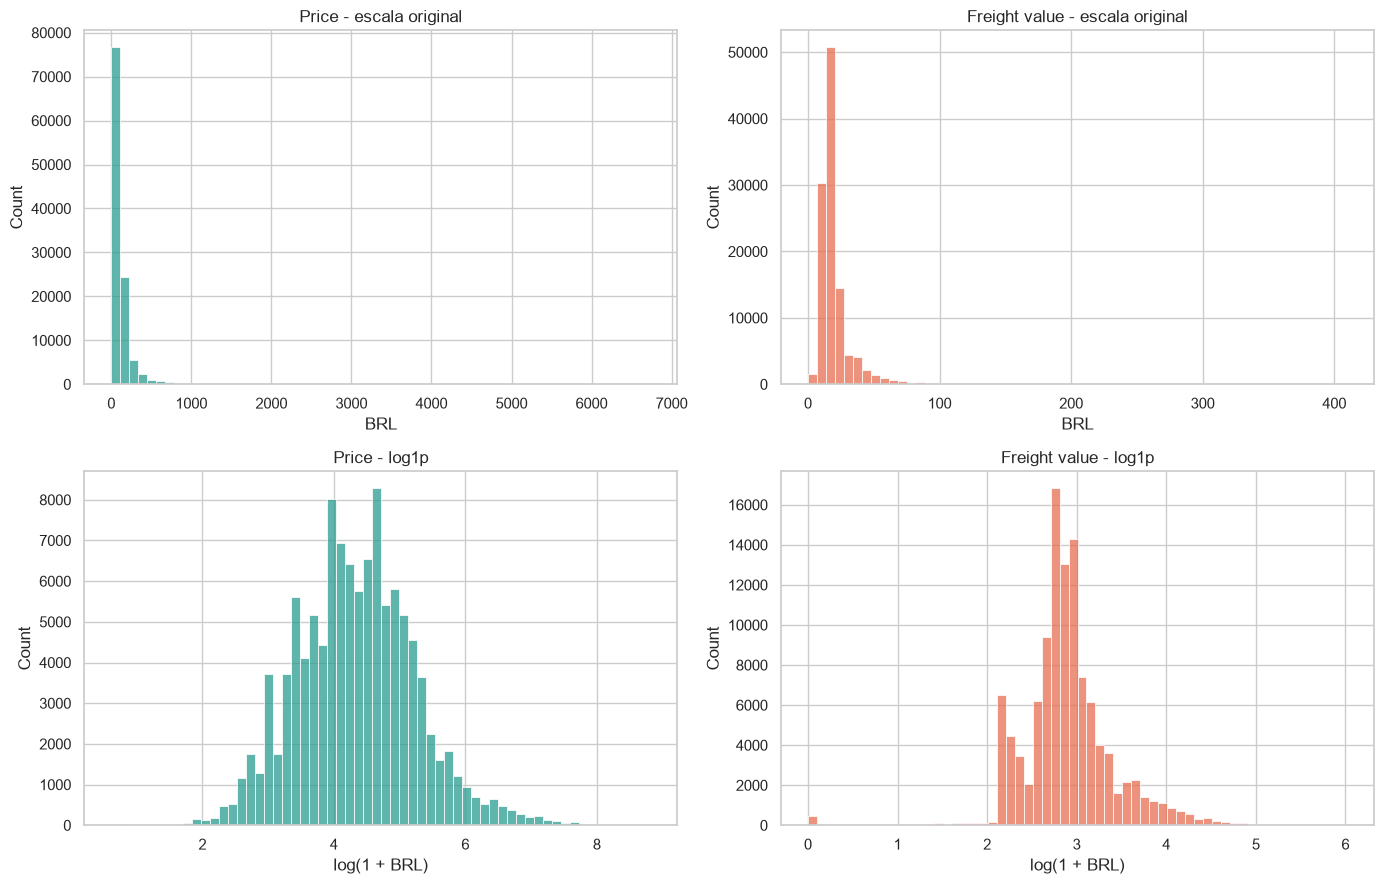

Distribución de payment_type:


,payment_type,payments
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


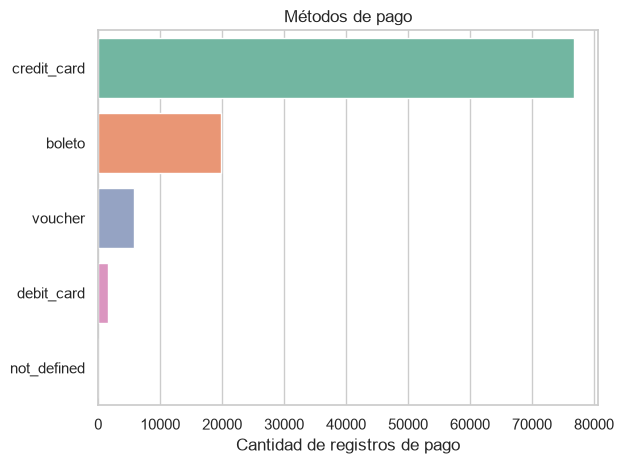

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, column, title, color in [
    (axes[0, 0], "price", "Price", "#2a9d8f"),
    (axes[0, 1], "freight_value", "Freight value", "#e76f51"),
]:
    sns.histplot(datasets["order_items"][column], bins=60, ax=axis, color=color)
    axis.set_title(f"{title} - escala original")
    axis.set_xlabel("BRL")
for axis, column, title, color in [
    (axes[1, 0], "price", "Price", "#2a9d8f"),
    (axes[1, 1], "freight_value", "Freight value", "#e76f51"),
]:
    sns.histplot(np.log1p(datasets["order_items"][column]), bins=60, ax=axis, color=color)
    axis.set_title(f"{title} - log1p")
    axis.set_xlabel("log(1 + BRL)")
plt.tight_layout()
plt.show()

payment_distribution = datasets["order_payments"]["payment_type"].value_counts().rename_axis("payment_type").reset_index(name="payments")
print("Distribución de payment_type:")
display(payment_distribution)
sns.barplot(data=payment_distribution, x="payments", y="payment_type", hue="payment_type", legend=False, palette="Set2")
plt.title("Métodos de pago")
plt.xlabel("Cantidad de registros de pago")
plt.ylabel("")
plt.tight_layout()
plt.show()

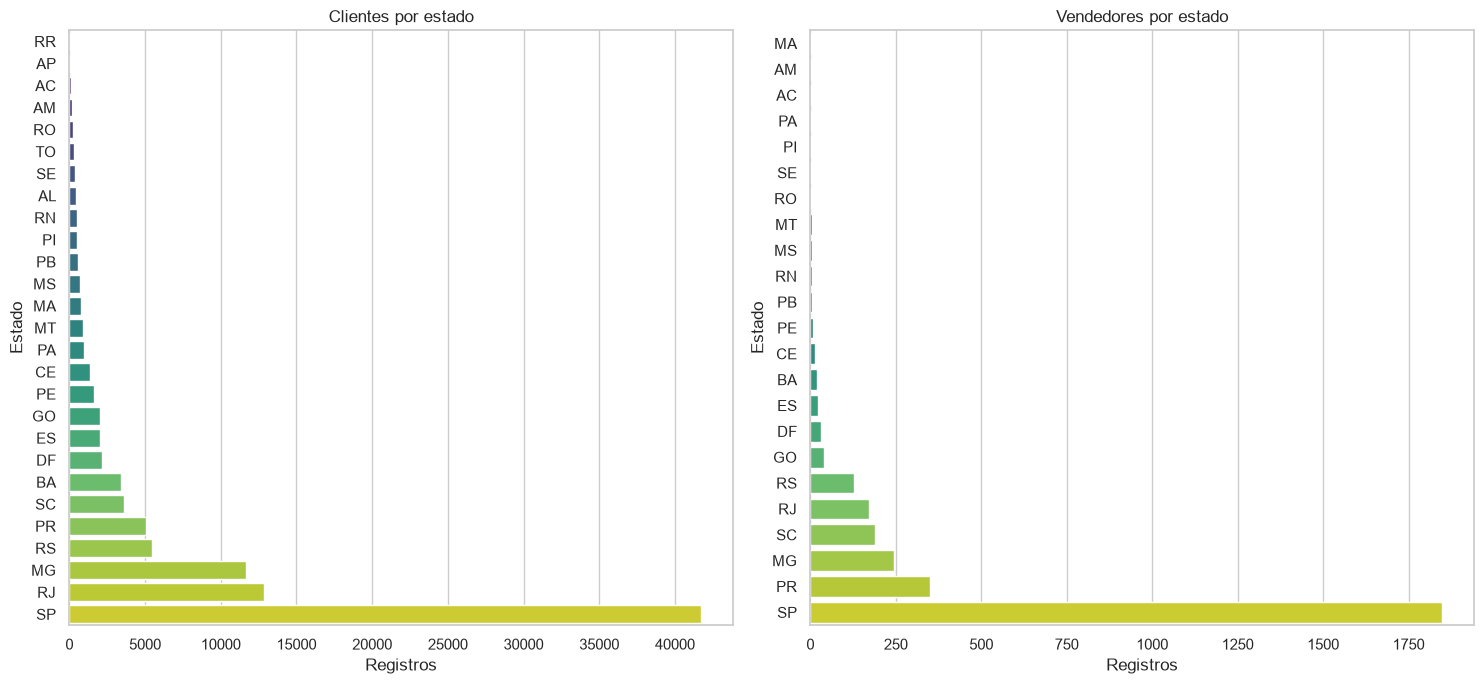

Clientes y vendedores por macro-región:


,customers,sellers
region,,
Sudeste,68266,2287
Nordeste,9394,56
Sul,14148,668
Centro-Oeste,5782,79
Norte,1851,5


Freight promedio por estado del vendedor y región del cliente:


customer_region,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
seller_state,,,,,
AC,NaN,NaN,NaN,32.84,NaN
AM,NaN,28.25,NaN,25.29,NaN
BA,29.95,23.11,46.29,33.01,36.42
CE,65.46,32.76,85.61,47.92,51.45
DF,13.07,27.70,28.84,19.62,27.31
ES,36.90,40.46,68.90,28.51,39.89
GO,14.69,33.37,26.50,24.12,29.58
MA,27.15,19.54,28.86,31.81,42.66
MG,27.06,34.22,42.16,21.14,28.56


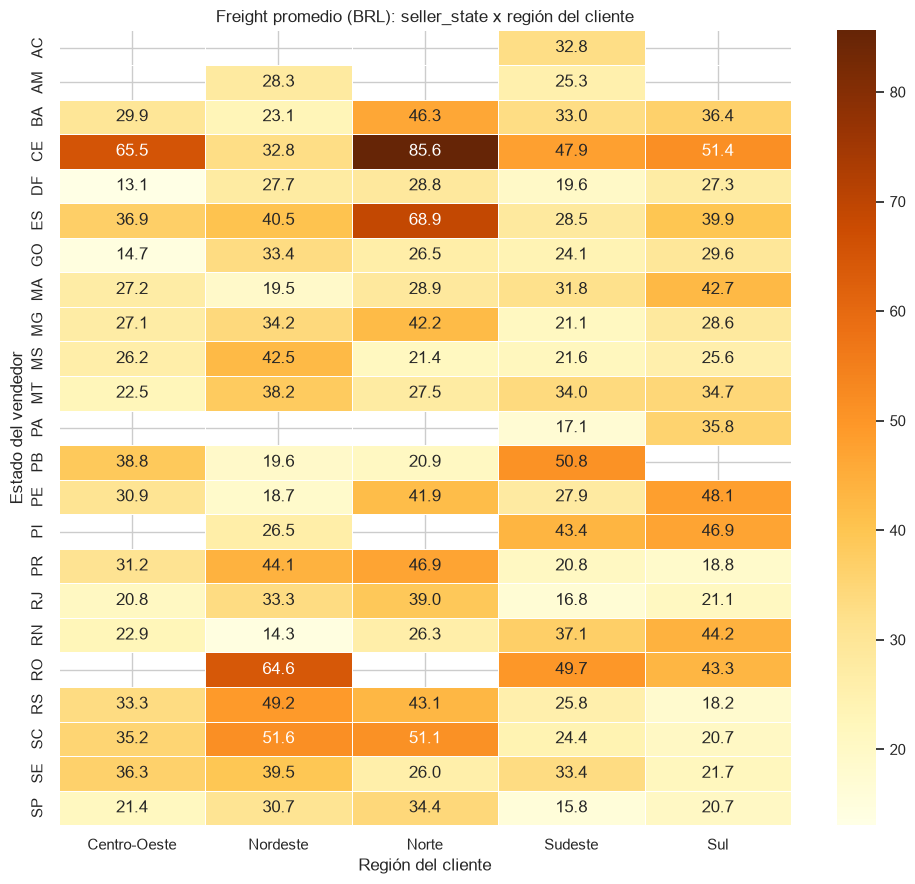

In [19]:
customers_geo = datasets["customers"].assign(region=lambda frame: frame["customer_state"].map(region_by_state))
sellers_geo = datasets["sellers"].assign(region=lambda frame: frame["seller_state"].map(region_by_state))
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for axis, frame, state_column, title in [
    (axes[0], customers_geo, "customer_state", "Clientes por estado"),
    (axes[1], sellers_geo, "seller_state", "Vendedores por estado"),
]:
    counts = frame[state_column].value_counts().sort_values()
    sns.barplot(x=counts.values, y=counts.index, ax=axis, hue=counts.index, legend=False, palette="viridis")
    axis.set_title(title)
    axis.set_xlabel("Registros")
    axis.set_ylabel("Estado")
plt.tight_layout()
plt.show()

region_counts = pd.DataFrame({
    "customers": customers_geo["region"].value_counts(),
    "sellers": sellers_geo["region"].value_counts(),
}).fillna(0).astype(int).reindex(["Sudeste", "Nordeste", "Sul", "Centro-Oeste", "Norte"])
print("Clientes y vendedores por macro-región:")
display(region_counts)

freight_region = items_analysis.pivot_table(index="seller_state", columns="customer_region", values="freight_value", aggfunc="mean")
print("Freight promedio por estado del vendedor y región del cliente:")
display(freight_region)
plt.figure(figsize=(10, 9))
sns.heatmap(freight_region, annot=True, fmt=".1f", cmap="YlOrBr", linewidths=.4)
plt.title("Freight promedio (BRL): seller_state x región del cliente")
plt.xlabel("Región del cliente")
plt.ylabel("Estado del vendedor")
plt.tight_layout()
plt.show()

Cantidad real de ítems por pedido vs review_score promedio (mínimo 20 pedidos por grupo):


,real_item_count,orders,average_review_score
0,1,88863,4.16
1,2,7516,3.65
2,3,1322,3.51
3,4,505,3.34
4,5,204,3.37
5,6,198,3.32
6,7,22,2.91


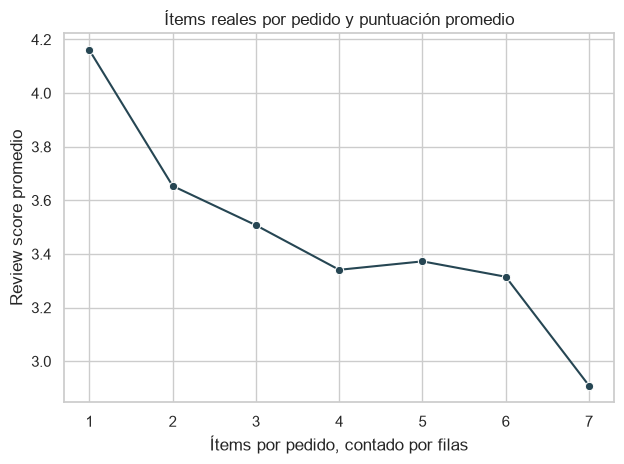

Pedidos con fecha real y estimada comparables: 96,476
Entrega promedio real: 12.56 días
Entrega promedio estimada: 23.74 días
Pedidos entregados tarde: 8.11%


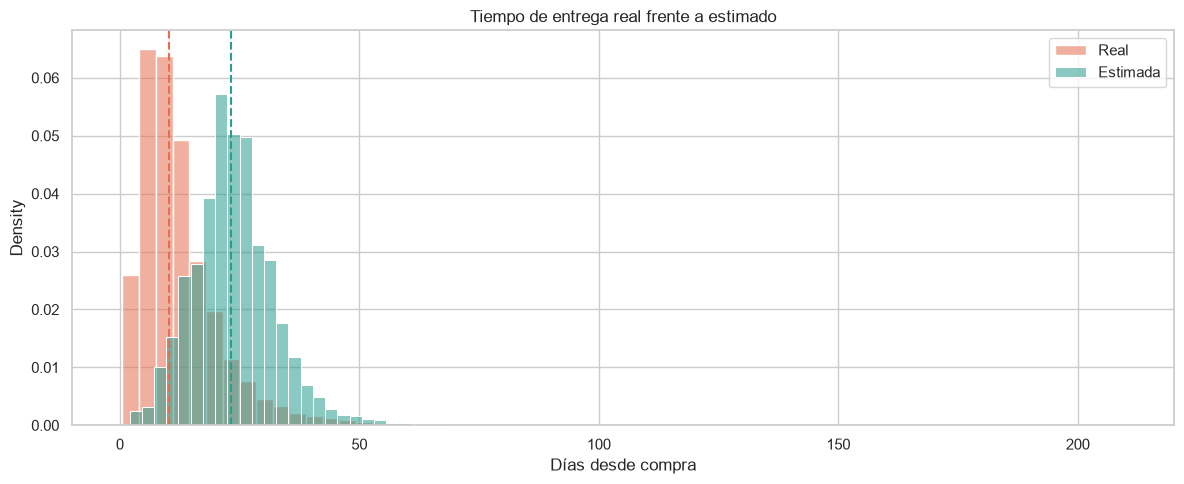

In [20]:
review_by_order = datasets["order_reviews"].groupby("order_id", as_index=False).agg(review_score=("review_score", "mean"))
items_reviews = items_per_order.reset_index().merge(review_by_order, on="order_id", how="left", validate="one_to_one")
score_by_item_count = items_reviews.groupby("real_item_count", as_index=False).agg(
    orders=("order_id", "nunique"),
    average_review_score=("review_score", "mean"),
).query("orders >= 20")
print("Cantidad real de ítems por pedido vs review_score promedio (mínimo 20 pedidos por grupo):")
display(score_by_item_count)
sns.lineplot(data=score_by_item_count, x="real_item_count", y="average_review_score", marker="o", color="#264653")
plt.title("Ítems reales por pedido y puntuación promedio")
plt.xlabel("Ítems por pedido, contado por filas")
plt.ylabel("Review score promedio")
plt.tight_layout()
plt.show()

logistics = orders_analysis.dropna(subset=["delivery_days", "estimated_days"]).copy()
late_pct = logistics["is_late"].mean() * 100
print(f"Pedidos con fecha real y estimada comparables: {len(logistics):,}")
print(f"Entrega promedio real: {logistics['delivery_days'].mean():.2f} días")
print(f"Entrega promedio estimada: {logistics['estimated_days'].mean():.2f} días")
print(f"Pedidos entregados tarde: {late_pct:.2f}%")
plt.figure(figsize=(12, 5))
sns.histplot(logistics["delivery_days"], bins=60, stat="density", alpha=.55, label="Real", color="#e76f51")
sns.histplot(logistics["estimated_days"], bins=60, stat="density", alpha=.55, label="Estimada", color="#2a9d8f")
plt.axvline(logistics["delivery_days"].median(), color="#e76f51", linestyle="--")
plt.axvline(logistics["estimated_days"].median(), color="#2a9d8f", linestyle="--")
plt.title("Tiempo de entrega real frente a estimado")
plt.xlabel("Días desde compra")
plt.legend()
plt.tight_layout()
plt.show()

Top 10 categorías por volumen de líneas vendidas:


,category,sales_volume,average_ticket,sales_value
7,bed_bath_table,11115,93.30,"1,036,988.68"
43,health_beauty,9670,130.16,"1,258,681.34"
67,sports_leisure,8641,114.34,"988,048.97"
39,furniture_decor,8334,87.56,"729,762.49"
15,computers_accessories,7827,116.51,"911,954.32"
49,housewares,6964,90.79,"632,248.66"
73,watches_gifts,5991,201.14,"1,205,005.68"
70,telephony,4545,71.21,"323,667.53"
42,garden_tools,4347,111.63,"485,256.46"
5,auto,4235,139.96,"592,720.11"


Top 10 categorías por ticket promedio de línea:


,category,sales_volume,average_ticket,sales_value
14,computers,203,"1,098.34","222,963.13"
66,small_appliances_home_oven_and_coffee,76,624.29,"47,445.71"
45,home_appliances_2,238,476.12,"113,317.74"
0,agro_industry_and_commerce,212,342.12,"72,530.47"
56,musical_instruments,680,281.62,"191,498.88"
65,small_appliances,679,280.78,"190,648.58"
62,portateis_cozinha_e_preparadores_de_alimentos,15,264.57,"3,968.53"
34,fixed_telephony,264,225.69,"59,583.00"
19,construction_tools_safety,194,208.99,"40,544.52"
73,watches_gifts,5991,201.14,"1,205,005.68"


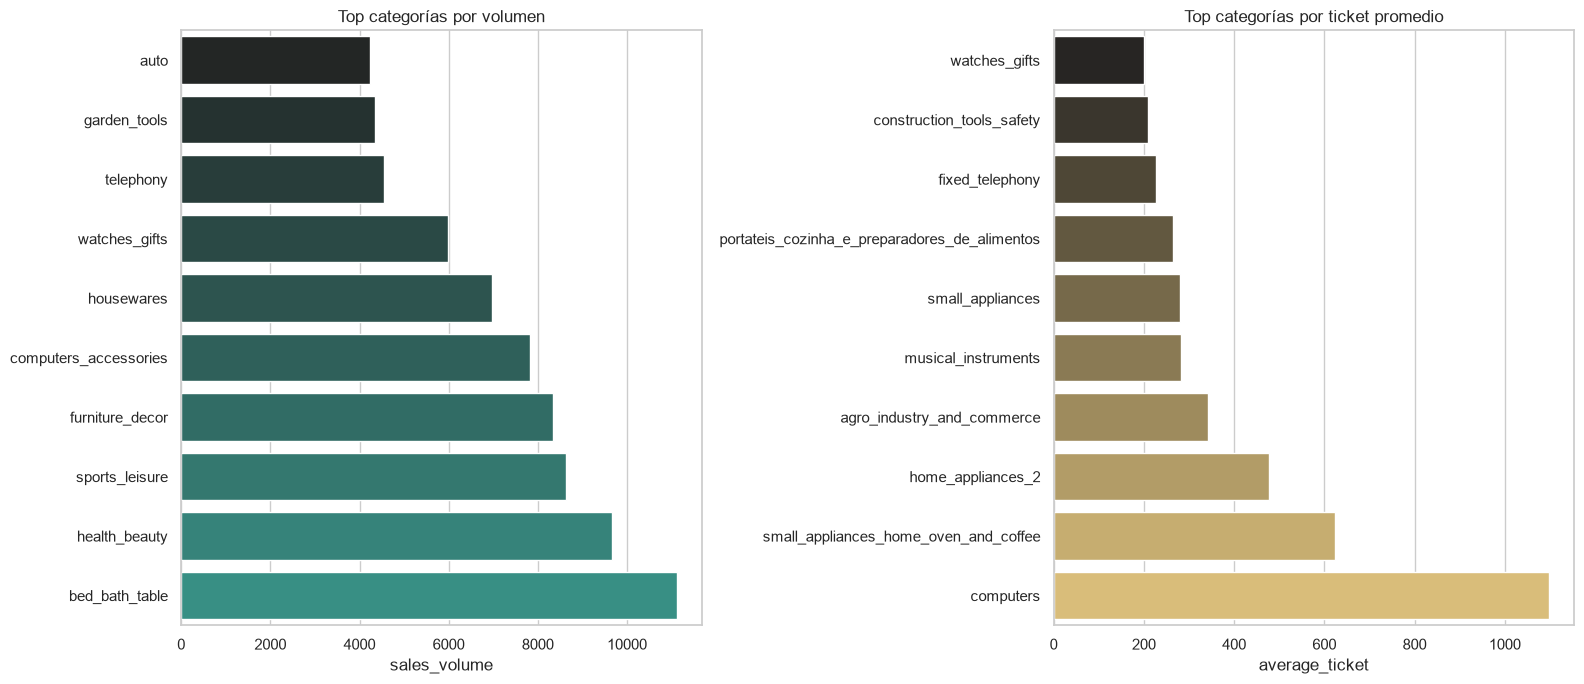

In [21]:
category_metrics = items_analysis.assign(
    category=items_analysis["product_category_name_english"].fillna(items_analysis["product_category_name"]).fillna("unknown")
).groupby("category", as_index=False).agg(
    sales_volume=("order_id", "size"),
    average_ticket=("price", "mean"),
    sales_value=("price", "sum"),
)
print("Top 10 categorías por volumen de líneas vendidas:")
display(category_metrics.nlargest(10, "sales_volume"))
print("Top 10 categorías por ticket promedio de línea:")
display(category_metrics.nlargest(10, "average_ticket"))
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for axis, metric, title, color in [
    (axes[0], "sales_volume", "Top categorías por volumen", "#2a9d8f"),
    (axes[1], "average_ticket", "Top categorías por ticket promedio", "#e9c46a"),
]:
    top = category_metrics.nlargest(10, metric).sort_values(metric)
    sns.barplot(data=top, x=metric, y="category", ax=axis, hue="category", legend=False, color=color)
    axis.set_title(title)
    axis.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Conclusiones para el modelo estrella

### `dim_customer`
- Origen `olist_customers_dataset.csv`: `customer_id` como clave operacional, `customer_unique_id`, `customer_zip_code_prefix`, `customer_city` y `customer_state`.
- Transformación: derivar `customer_region` desde `customer_state` con el catálogo de cinco macro-regiones; conservar un miembro `unknown` si la relación geográfica no existe.

### `dim_product`
- Origen `olist_products_dataset.csv`: `product_id`, `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty`, `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`.
- Origen `product_category_name_translation.csv`: traducir `product_category_name` a `product_category_name_english` mediante una relación `N:1`; imputar la categoría faltante como `unknown` sin eliminar el producto.

### `dim_seller`
- Origen `olist_sellers_dataset.csv`: `seller_id`, `seller_zip_code_prefix`, `seller_city` y `seller_state`.
- Transformación: derivar `seller_region` desde `seller_state`; la geolocalización detallada puede mantenerse como tabla auxiliar porque tiene múltiples coordenadas por prefijo.

### `dim_date`
- Origen principal `olist_orders_dataset.csv`: `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` y `order_estimated_delivery_date`.
- Transformación: crear una fila por fecha y derivar `date_key`, año, trimestre, mes, nombre de mes, semana, día y día de semana. La fecha de compra puede ser la dimensión de rol principal; las demás son claves de fecha con roles distintos.

### `fact_sales`
- Grano recomendado: una fila por `order_id` + `order_item_id`.
- Origen `olist_order_items_dataset.csv`: `order_id`, `order_item_id`, `product_id`, `seller_id`, `shipping_limit_date`, `price`, `freight_value`.
- Origen `olist_orders_dataset.csv`: `customer_id`, `order_status` y fechas de ciclo logístico; derivar `delivery_days`, `estimated_days` e `is_late`.
- Origen `olist_order_reviews_dataset.csv`: agregar `review_score` a nivel pedido antes de incorporarlo; no unir reseñas crudas si hay varias por pedido.
- Origen `olist_order_payments_dataset.csv`: mantener como `fact_payment` o agregar por pedido (`payment_value` total, número de pagos, tipos concatenados); no unir pagos crudos a líneas porque crea un producto cartesiano parcial.
- Cálculos: `item_count` es el conteo de filas por `order_id`; nunca usar `order_item_id` como cantidad. Los importes de pagos y ventas deben conservarse como métricas distintas y reconciliarse con reglas de negocio.

El diseño conserva las granularidades originales, hace explícitas las relaciones y permite que PostgreSQL y Power BI calculen ventas, logística, satisfacción y distribución geográfica sin doble conteo.